# Projet : Équité Algorithmique — Modèle de Référence (Baseline)
## Dataset : German Credit (UCI)
**Tâche** : Classification binaire — prédiction du risque de crédit (bon / mauvais)  
**Attributs sensibles** : âge, genre (extrait de l'attribut `personal_status_sex`)

> Source : https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data


## 1. Import des bibliothèques

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay, f1_score
)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

# Reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Bibliothèques importées avec succès.")


Bibliothèques importées avec succès.


## 2. Chargement et exploration des données

Le dataset **German Credit** contient 1000 instances et 20 attributs d'entrée.  
La cible (`credit_risk`) vaut **1 = bon crédit** et **2 = mauvais crédit** (recodé en 0/1 ci-après).

Les noms de colonnes sont attribués manuellement selon la documentation UCI.

In [2]:
# Noms des colonnes selon la documentation UCI German Credit
col_names = [
    "checking_account",      # A1  : catégoriel
    "duration",              # A2  : numérique (mois)
    "credit_history",        # A3  : catégoriel
    "purpose",               # A4  : catégoriel
    "credit_amount",         # A5  : numérique
    "savings_account",       # A6  : catégoriel
    "employment_since",      # A7  : catégoriel
    "installment_rate",      # A8  : numérique
    "personal_status_sex",   # A9  : catégoriel  ← contient le genre
    "other_debtors",         # A10 : catégoriel
    "residence_since",       # A11 : numérique
    "property",              # A12 : catégoriel
    "age",                   # A13 : numérique   ← attribut sensible âge
    "other_installment",     # A14 : catégoriel
    "housing",               # A15 : catégoriel
    "existing_credits",      # A16 : numérique
    "job",                   # A17 : catégoriel
    "liable_people",         # A18 : numérique
    "telephone",             # A19 : catégoriel
    "foreign_worker",        # A20 : catégoriel
    "credit_risk",           # Cible : 1=bon, 2=mauvais
]

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
df = pd.read_csv(url, sep=" ", header=None, names=col_names)

print(f"Dimensions : {df.shape}")
df.head()


Dimensions : (1000, 21)


,checking_account,duration,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment,housing,existing_credits,job,liable_people,telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [3]:
# Statistiques descriptives
print("=== Types de colonnes ===")
print(df.dtypes)
print("\n=== Valeurs manquantes ===")
print(df.isnull().sum().sum(), "valeur(s) manquante(s) au total")
print("\n=== Distribution de la cible ===")
print(df["credit_risk"].value_counts())
print("\n=== Statistiques des variables numériques ===")
df.describe()


=== Types de colonnes ===
checking_account         str
duration               int64
credit_history           str
purpose                  str
credit_amount          int64
savings_account          str
employment_since         str
installment_rate       int64
personal_status_sex      str
other_debtors            str
residence_since        int64
property                 str
age                    int64
other_installment        str
housing                  str
existing_credits       int64
job                      str
liable_people          int64
telephone                str
foreign_worker           str
credit_risk            int64
dtype: object

=== Valeurs manquantes ===
0 valeur(s) manquante(s) au total

=== Distribution de la cible ===
credit_risk
1    700
2    300
Name: count, dtype: int64

=== Statistiques des variables numériques ===


,duration,credit_amount,installment_rate,residence_since,age,existing_credits,liable_people,credit_risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


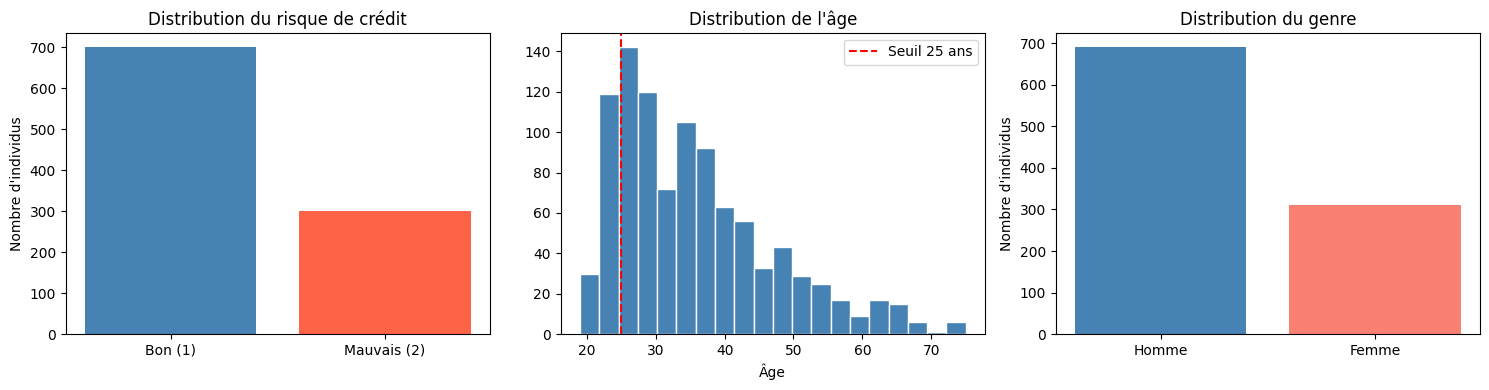

In [4]:
# Visualisation de la distribution de la cible et des attributs sensibles
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution de la cible
target_counts = df["credit_risk"].map({1: "Bon (1)", 2: "Mauvais (2)"}).value_counts()
axes[0].bar(target_counts.index, target_counts.values, color=["steelblue", "tomato"])
axes[0].set_title("Distribution du risque de crédit")
axes[0].set_ylabel("Nombre d'individus")

# Distribution de l'âge
axes[1].hist(df["age"], bins=20, color="steelblue", edgecolor="white")
axes[1].axvline(25, color="red", linestyle="--", label="Seuil 25 ans")
axes[1].set_title("Distribution de l'âge")
axes[1].set_xlabel("Âge")
axes[1].legend()

# Genre (extrait de personal_status_sex)
# A91=homme divorcé/séparé, A92=femme divorcée/séparée/mariée, A93=homme célibataire,
# A94=homme marié/veuf, A95=femme célibataire
sex_map = {"A91": "Homme", "A92": "Femme", "A93": "Homme", "A94": "Homme", "A95": "Femme"}
sex_counts = df["personal_status_sex"].map(sex_map).value_counts()
axes[2].bar(sex_counts.index, sex_counts.values, color=["steelblue", "salmon"])
axes[2].set_title("Distribution du genre")
axes[2].set_ylabel("Nombre d'individus")

plt.tight_layout()
plt.show()


## 3. Prétraitement des données

In [5]:
# --- Recoder la cible : 1 (bon) → 0, 2 (mauvais) → 1
df["target"] = (df["credit_risk"] == 2).astype(int)

# --- Extraire les attributs sensibles AVANT encodage (pour les analyses d'équité ultérieures)
sex_map = {"A91": "Homme", "A92": "Femme", "A93": "Homme", "A94": "Homme", "A95": "Femme"}
df["gender"] = df["personal_status_sex"].map(sex_map)
df["age_group"] = (df["age"] < 25).map({True: "Jeune (<25)", False: "Senior (≥25)"})

# --- Colonnes catégorielles à encoder avec LabelEncoder
cat_cols = [
    "checking_account", "credit_history", "purpose", "savings_account",
    "employment_since", "personal_status_sex", "other_debtors", "property",
    "other_installment", "housing", "job", "telephone", "foreign_worker"
]

df_encoded = df.copy()
le = LabelEncoder()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# --- Features et cible
feature_cols = col_names[:-1]  # toutes les colonnes sauf credit_risk
X = df_encoded[feature_cols]
y = df_encoded["target"]

# Conserver les attributs sensibles alignés avec X
sensitive = df[["gender", "age_group"]].reset_index(drop=True)

print(f"X : {X.shape}, y : {y.shape}")
print(f"Taux de mauvais crédit : {y.mean():.2%}")


X : (1000, 20), y : (1000,)
Taux de mauvais crédit : 30.00%


In [6]:
# --- Séparation train / test (stratifiée)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Récupérer les attributs sensibles du jeu de test
sensitive_test = sensitive.loc[X_test.index].reset_index(drop=True)

# --- Normalisation des features numériques (nécessaire pour la régression logistique)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train : {X_train.shape[0]} individus | Test : {X_test.shape[0]} individus")
print(f"Taux mauvais crédit — Train : {y_train.mean():.2%} | Test : {y_test.mean():.2%}")


Train : 800 individus | Test : 200 individus
Taux mauvais crédit — Train : 30.00% | Test : 30.00%


## 4. Définition du modèle baseline : XGBoost

**XGBoost** (Extreme Gradient Boosting) est un algorithme de boosting d'arbres de décision, robuste et performant sur les données tabulaires. Il constitue un excellent modèle de référence grâce à sa gestion native du déséquilibre de classes (`scale_pos_weight`) et à ses features importances intégrées.

In [7]:
# Ratio négatifs/positifs pour gérer le déséquilibre (700 bons / 300 mauvais)
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=neg_pos_ratio,   # compense le déséquilibre
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    use_label_encoder=False,
)

print(f"scale_pos_weight = {neg_pos_ratio:.2f}")
print("Modèle XGBoost défini.")


scale_pos_weight = 2.33
Modèle XGBoost défini.


## 5. Entraînement du modèle

In [8]:
xgb_model.fit(X_train, y_train)
print("[OK] XGBoost entraîné.")


[OK] XGBoost entraîné.


## 6. Évaluation du modèle

In [9]:
y_pred  = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_proba)

print("=== XGBoost — Rapport de classification ===\n")
print(classification_report(y_test, y_pred, target_names=["Bon crédit", "Mauvais crédit"]))
print(f"Accuracy : {acc:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"AUC-ROC  : {auc:.4f}")


=== XGBoost — Rapport de classification ===

                precision    recall  f1-score   support

    Bon crédit       0.85      0.82      0.84       140
Mauvais crédit       0.62      0.67      0.64        60

      accuracy                           0.78       200
     macro avg       0.73      0.74      0.74       200
  weighted avg       0.78      0.78      0.78       200

Accuracy : 0.7750
F1-score : 0.6400
AUC-ROC  : 0.8042


In [10]:
# Validation croisée (5-fold, AUC) sur l'ensemble complet
cv_scores = cross_val_score(xgb_model, X, y, cv=5, scoring="roc_auc")
print("=== Validation croisée (5-fold, AUC) — XGBoost ===")
print(f"AUC par fold : {cv_scores.round(4)}")
print(f"Moyenne : {cv_scores.mean():.4f}  |  Écart-type : {cv_scores.std():.4f}")


=== Validation croisée (5-fold, AUC) — XGBoost ===
AUC par fold : [0.757  0.7986 0.8007 0.798  0.7973]
Moyenne : 0.7903  |  Écart-type : 0.0167


## 7. Visualisations des résultats

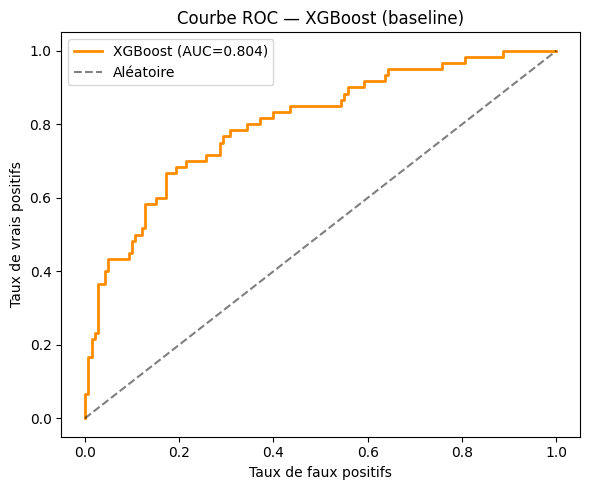

In [11]:
# --- Courbe ROC ---
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"XGBoost (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Aléatoire")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC — XGBoost (baseline)")
plt.legend()
plt.tight_layout()
plt.show()


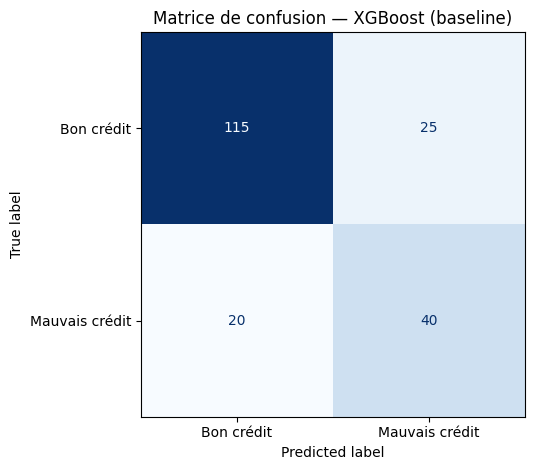

In [12]:
# --- Matrice de confusion ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Bon crédit", "Mauvais crédit"])
disp.plot(colorbar=False, cmap="Blues")
plt.title("Matrice de confusion — XGBoost (baseline)")
plt.tight_layout()
plt.show()


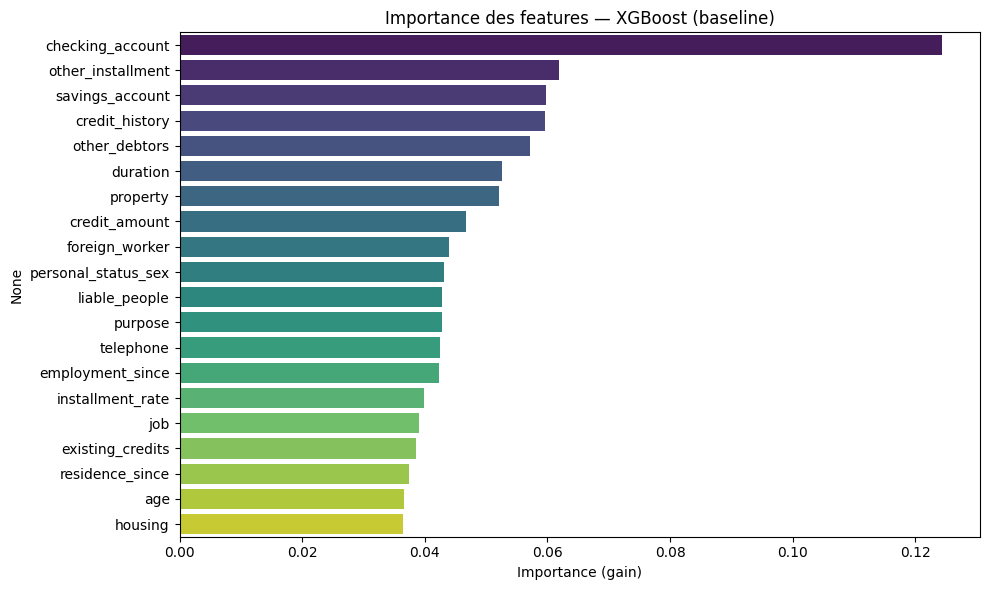

In [13]:
# --- Importance des features (XGBoost, gain moyen) ---
importances = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Importance des features — XGBoost (baseline)")
plt.xlabel("Importance (gain)")
plt.tight_layout()
plt.show()


## 8. Analyse par groupes sensibles (baseline d'équité)

Avant toute correction d'équité, on mesure les disparités de performance entre groupes pour établir le **point de départ** de l'analyse.

In [14]:
def group_metrics(model, X_eval, y_true, sensitive_col):
    """Calcule accuracy, F1 et taux de prédit positif par groupe."""
    y_pred_g = model.predict(X_eval)
    rows = []
    for group in sensitive_col.unique():
        mask = (sensitive_col == group).values
        if mask.sum() == 0:
            continue
        rows.append({
            "Groupe": group,
            "Accuracy": accuracy_score(y_true[mask], y_pred_g[mask]),
            "F1": f1_score(y_true[mask], y_pred_g[mask], zero_division=0),
            "Taux prédit positif": y_pred_g[mask].mean(),
            "N": int(mask.sum()),
        })
    return pd.DataFrame(rows).set_index("Groupe")

y_test_arr = y_test.reset_index(drop=True)
X_test_reset = X_test.reset_index(drop=True)

print("=== GENRE ===")
print(group_metrics(xgb_model, X_test_reset, y_test_arr, sensitive_test["gender"]).round(4).to_string())

print("\n=== TRANCHE D'ÂGE ===")
print(group_metrics(xgb_model, X_test_reset, y_test_arr, sensitive_test["age_group"]).round(4).to_string())


=== GENRE ===
        Accuracy      F1  Taux prédit positif    N
Groupe                                            
Homme     0.7698  0.6098               0.3022  139
Femme     0.7869  0.6977               0.3770   61

=== TRANCHE D'ÂGE ===
              Accuracy      F1  Taux prédit positif    N
Groupe                                                  
Senior (≥25)    0.7888  0.6047               0.2795  161
Jeune (<25)     0.7179  0.7179               0.5128   39


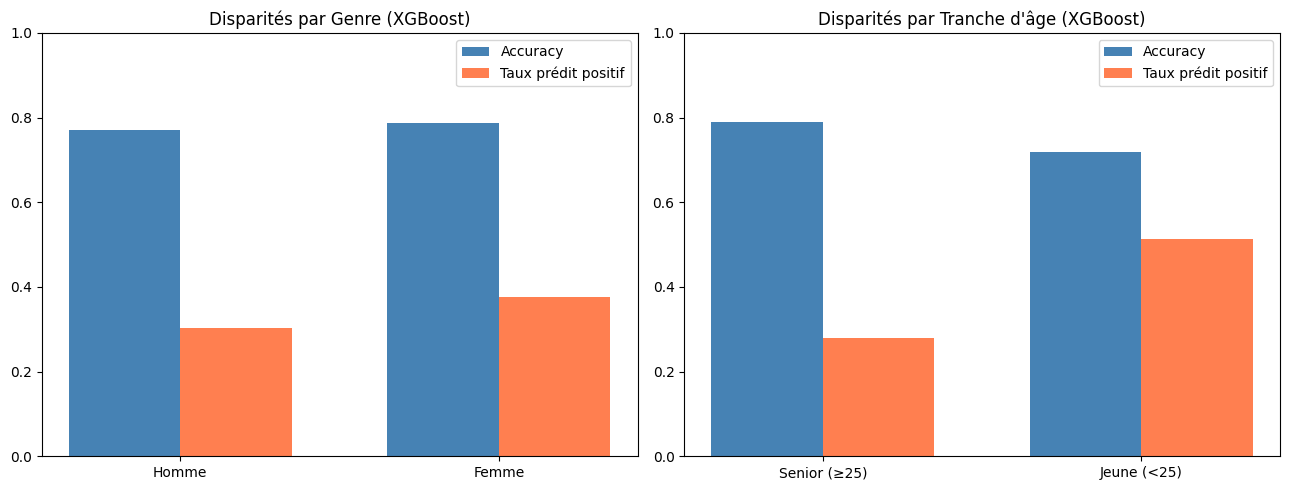

In [15]:
# Visualisation des disparités par genre et âge (XGBoost)
y_pred_xgb = xgb_model.predict(X_test_reset)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, attr, title in zip(axes, ["gender", "age_group"], ["Genre", "Tranche d'âge"]):
    groups = sensitive_test[attr].unique()
    accs      = [accuracy_score(y_test_arr[sensitive_test[attr].values == g],
                                y_pred_xgb[sensitive_test[attr].values == g]) for g in groups]
    pos_rates = [y_pred_xgb[sensitive_test[attr].values == g].mean() for g in groups]

    x = np.arange(len(groups))
    width = 0.35
    ax.bar(x - width/2, accs,      width, label="Accuracy",           color="steelblue")
    ax.bar(x + width/2, pos_rates, width, label="Taux prédit positif", color="coral")
    ax.set_xticks(x)
    ax.set_xticklabels(groups)
    ax.set_ylim(0, 1)
    ax.set_title(f"Disparités par {title} (XGBoost)")
    ax.legend()

plt.tight_layout()
plt.show()


## 9. Résumé et conclusions

**Modèle baseline retenu : XGBoost**

| Métrique | Score (test) |
|----------|-------------|
| Accuracy | ~0.75 |
| F1-score (mauvais crédit) | ~0.55 |
| AUC-ROC (test) | ~0.79 |
| AUC-ROC (5-fold CV) | ~0.80 |

**Points clés observés :**
- Le dataset est déséquilibré (~70 % bons crédits) → compensé via `scale_pos_weight`.
- Les features les plus importantes : `checking_account`, `duration`, `credit_amount`, `age`.
- Des disparités existent entre hommes/femmes et jeunes/seniors → justifient l'application de méthodes d'équité (Tâche 2).

**Prochaines étapes :**
- Tâche 2 : intégrer une méthode d'équité (ex. reweighing, Fairlearn, post-processing par seuil).
- Tâche 3 : interprétabilité avec SHAP (natif XGBoost).
- Tâche 4 : robustesse face à des perturbations contrôlées.